### 1. Extract the Archive
We will extract `archive.zip` directly into the current directory.

In [1]:
import zipfile
import os

zip_path = './data/archive.zip'
extract_path = './data/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Extracted to {os.path.abspath(extract_path)}")

Extracted to c:\Users\Asus\Desktop\Facial Emotion Detection\notebooks\data


###  Count Images and Plot Distribution
Assuming the extracted data is organized in subdirectories where each folder name is a class label.

Image counts per subdirectory: {'angry': 5920, 'disgust': 5920, 'fear': 5920, 'happy': 11398, 'neutral': 8166, 'sad': 6535, 'surprise': 5920}


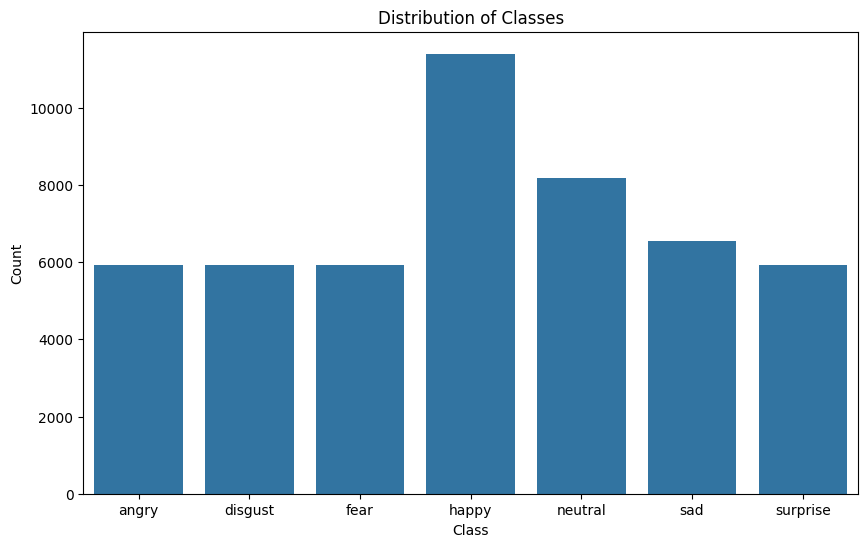

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


data_dir = './data/processed_data' 

class_counts = {}
for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

print("Image counts per subdirectory:", class_counts)

# Plotting
df_counts = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])
plt.figure(figsize=(10, 6))
sns.barplot(data=df_counts, x='Class', y='Count')
plt.title('Distribution of Classes')
plt.show()

### Show Random Images and Explore Shapes

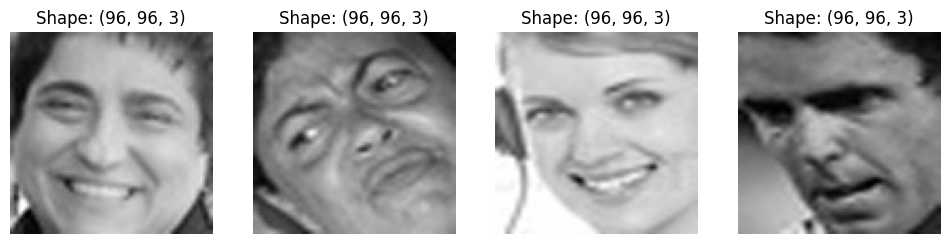

In [3]:
from PIL import Image
import random
import numpy as np

# Get a few random image paths
all_images = []
for root, dirs, files in os.walk(data_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_images.append(os.path.join(root, file))

sample_paths = random.sample(all_images, 4)

plt.figure(figsize=(12, 6))
for i, img_path in enumerate(sample_paths):
    img = Image.open(img_path)
    plt.subplot(1, 4, i+1)
    plt.imshow(img)
    plt.title(f"Shape: {np.array(img).shape}")
    plt.axis('off')
plt.show()

### Torchvision Transforms and Data Splitting
We will define the augmentations and use `random_split` to divide the dataset.

In [4]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Define transformations
data_transforms = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load dataset
full_dataset = datasets.ImageFolder(root=data_dir, transform=None)

# Split sizes
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

Train size: 34845
Val size: 7466
Test size: 7468


### Further EDA: Data Integrity and Dimensions
We'll check a larger sample of the dataset to verify that all images are readable and check if there's any variation in original dimensions.

In [5]:
from tqdm import tqdm

dims = []
corrupt_files = []

# Sample 500 images to check dimensions and integrity
sample_check = random.sample(all_images, min(500, len(all_images)))

for img_path in tqdm(sample_check, desc="Checking integrity"):
    try:
        with Image.open(img_path) as img:
            dims.append(img.size)
    except Exception:
        corrupt_files.append(img_path)

print(f"\nCorrupt files found: {len(corrupt_files)}")
dim_df = pd.DataFrame(dims, columns=['Width', 'Height'])
display(dim_df.describe())

if corrupt_files:
    print("List of corrupt files:", corrupt_files)

Checking integrity: 100%|██████████| 500/500 [00:00<00:00, 3316.08it/s]


Corrupt files found: 0


,Width,Height
count,500.0,500.0
mean,96.0,96.0
std,0.0,0.0
min,96.0,96.0
25%,96.0,96.0
50%,96.0,96.0
75%,96.0,96.0
max,96.0,96.0


### Class Distribution After Splitting
It's important to verify that our `random_split` didn't introduce significant bias into any of the subsets.

,Train,Validation,Test
angry,4193,889,838
disgust,4196,873,851
fear,4168,893,859
happy,7970,1703,1725
neutral,5653,1236,1277
sad,4541,982,1012
surprise,4124,890,906


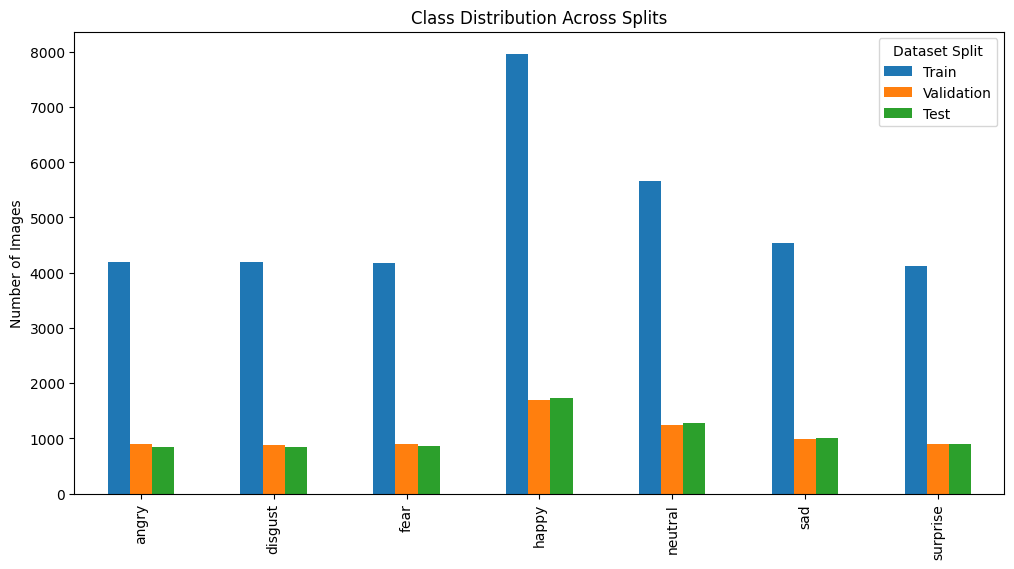

In [6]:
def get_split_distribution(dataset, subset_name):
    # Extract targets from the subset indices
    indices = dataset.indices
    targets = [dataset.dataset.targets[i] for i in indices]
    class_names = dataset.dataset.classes
    counts = pd.Series(targets).value_counts().sort_index()
    counts.index = [class_names[i] for i in counts.index]
    return counts.to_frame(name=subset_name)

train_dist = get_split_distribution(train_dataset, 'Train')
val_dist = get_split_distribution(val_dataset, 'Validation')
test_dist = get_split_distribution(test_dataset, 'Test')

# Combine and plot
dist_df = pd.concat([train_dist, val_dist, test_dist], axis=1)
display(dist_df)

dist_df.plot(kind='bar', figsize=(12, 6))
plt.title('Class Distribution Across Splits')
plt.ylabel('Number of Images')
plt.legend(title='Dataset Split')
plt.show()

### Physically Organize Data into Split Directories
This step creates a permanent directory structure on disk for the train, validation, and test sets.

In [7]:
import shutil
from tqdm import tqdm

def create_split_dirs(base_path, dataset, split_name):
    """Copies images from a Subset to a physical directory structure."""
    for i in tqdm(range(len(dataset)), desc=f"Creating {split_name} set"):
        # Get original path and label
        path, label_idx = dataset.dataset.samples[dataset.indices[i]]
        class_name = dataset.dataset.classes[label_idx]

        # Define destination
        target_dir = os.path.join(base_path, split_name, class_name)
        os.makedirs(target_dir, exist_ok=True)

        # Copy file
        shutil.copy(path, os.path.join(target_dir, os.path.basename(path)))

# Define the root directory for the split data
output_root = './data/final_dataset'

# Execute copying for each split
create_split_dirs(output_root, train_dataset, 'train')
create_split_dirs(output_root, val_dataset, 'val')
create_split_dirs(output_root, test_dataset, 'test')

print(f"\nDataset successfully organized in: {os.path.abspath(output_root)}")

Creating test set: 100%|██████████| 7468/7468 [00:11<00:00, 624.07it/s]


Dataset successfully organized in: c:\Users\Asus\Desktop\Facial Emotion Detection\notebooks\data\final_dataset


In [8]:
import shutil

# Remove the temporary processed_data directory
directory_to_delete = './data/processed_data'

if os.path.exists(directory_to_delete):
    shutil.rmtree(directory_to_delete)
    print(f"Successfully deleted: {directory_to_delete}")
else:
    print(f"Directory {directory_to_delete} does not exist.")

Successfully deleted: ./data/processed_data
